# LeetCode #111: Minimum Depth of Binary Tree

https://leetcode.com/problems/minimum-depth-of-binary-tree/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| DFS Recursive | O(n) | O(n) | min(left,right) with null-child guard |
| **BFS (First Leaf) ★** | **O(n)** | **O(n)** | Stop at first leaf found — optimal early exit |

---

## Understanding the Methods

### DFS Recursive
Key gotcha: if only left child exists, must recurse left (not return 1). Guard: `if (left==null) return 1+minDepth(right)`. Recursion visits all nodes → O(n).

### BFS First Leaf (Optimal ★)
BFS naturally finds the shallowest node first. The first leaf node encountered is by definition the minimum depth. Can stop immediately — great for wide shallow trees.

## Constraints
- Number of nodes: [0, 10⁵]
- Node values: [-1000, 1000]

## Solutions

### C#

In [ ]:
public class Solution {
    public int MinDepth(TreeNode root) {
        if (root == null) return 0;
        var queue = new Queue<(TreeNode node, int depth)>();
        queue.Enqueue((root, 1));
        while (queue.Count > 0) {
            var (node, depth) = queue.Dequeue();
            if (node.left == null && node.right == null) return depth;
            if (node.left  != null) queue.Enqueue((node.left,  depth + 1));
            if (node.right != null) queue.Enqueue((node.right, depth + 1));
        }
        return 0;
    }
}

### Python

In [ ]:
from collections import deque

class Solution:
    def minDepth(self, root) -> int:
        if not root: return 0
        queue = deque([(root, 1)])
        while queue:
            node, depth = queue.popleft()
            if not node.left and not node.right:
                return depth
            if node.left:  queue.append((node.left,  depth + 1))
            if node.right: queue.append((node.right, depth + 1))
        return 0

### Go

In [ ]:
type item struct {
    node  *TreeNode
    depth int
}

func minDepth(root *TreeNode) int {
    if root == nil { return 0 }
    queue := []item{{root, 1}}
    for len(queue) > 0 {
        cur   := queue[0]; queue = queue[1:]
        if cur.node.Left == nil && cur.node.Right == nil {
            return cur.depth
        }
        if cur.node.Left  != nil { queue = append(queue, item{cur.node.Left,  cur.depth+1}) }
        if cur.node.Right != nil { queue = append(queue, item{cur.node.Right, cur.depth+1}) }
    }
    return 0
}

### Rust

In [ ]:
use std::rc::Rc;
use std::cell::RefCell;
use std::collections::VecDeque;

impl Solution {
    pub fn min_depth(root: Option<Rc<RefCell<TreeNode>>>) -> i32 {
        let Some(r) = root else { return 0; };
        let mut queue = VecDeque::from([(r, 1i32)]);
        while let Some((node, depth)) = queue.pop_front() {
            let left  = node.borrow().left.clone();
            let right = node.borrow().right.clone();
            if left.is_none() && right.is_none() { return depth; }
            if let Some(l) = left  { queue.push_back((l, depth+1)); }
            if let Some(r) = right { queue.push_back((r, depth+1)); }
        }
        0
    }
}

## Example Scenarios

### 1. Common Case — Shallow Leaf on Left
**Input:** `root = [3, 9, 20, null, null, 15, 7]`

BFS level-by-level: dequeue root 3 (depth 1, not a leaf). Dequeue 9 (depth 2, both children null $\Rightarrow$ leaf). Return $d = 2$ immediately without visiting nodes 15 or 7.

*Why tricky:* Straightforward case — BFS naturally finds the shallowest leaf first.

**Output:** `2`

### 2. Slightly Complex — Only-Child Trap
**Input:** `root = [1, 2, null, 3, null, 4, null]` (left-only chain)

Node 1 has only a left child — it is NOT a leaf. A naive DFS using $\min(\text{left}, \text{right})$ would return 1 (treating null right as depth 0). BFS correctly skips non-leaves and finds the only leaf (node 4) at depth 4.

*Why tricky:* Classic interview trap. Nodes with one child are not leaves — the null-child guard is essential.

**Output:** `4`

### 3. Edge Case: Time Factor — 100,000-Node Left-Skewed Chain
**Input:** Left chain of $n = 10^5$ nodes, each having only a left child.

The only leaf is at depth $10^5$. BFS dequeues all $10^5$ nodes before reaching it. Queue size stays $O(1)$ (one node at a time), but time is $O(n)$ with no early exit possible.

*Why tricky:* Worst-case time — the single leaf is at maximum depth, forcing BFS to visit every node.

**Output:** `100000`

### 4. Edge Case: Space Factor — Perfect Tree of Depth 16
**Input:** Perfect binary tree, depth 16, $n = 2^{16} - 1 = 65535$ nodes.

All leaves are at depth 16. BFS must reach the last level. Queue peaks at $2^{15} = 32768$ nodes (the full bottom level). Space $= O(n/2)$.

*Why tricky:* Worst-case BFS space — the widest level holds half the tree in the queue simultaneously.

**Output:** `16`

### 5. Almost-Impossible but Plausible — 99,999 Deep Nodes + 1 Shallow Leaf
**Input:** Root has right child (leaf) and left child leading a chain of 99,998 nodes. Total $n = 10^5$.

BFS dequeues root (depth 1), then at depth 2: left child (not a leaf, has child) and right child (leaf!). Returns $d = 2$ after visiting only 3 nodes. The 99,998-node left chain is never explored.

*Why tricky:* Near-max input but BFS exits after 3 nodes — demonstrates the best-case early-exit advantage over DFS, which would recurse $10^5$ levels deep and likely stack-overflow.

**Output:** `2`

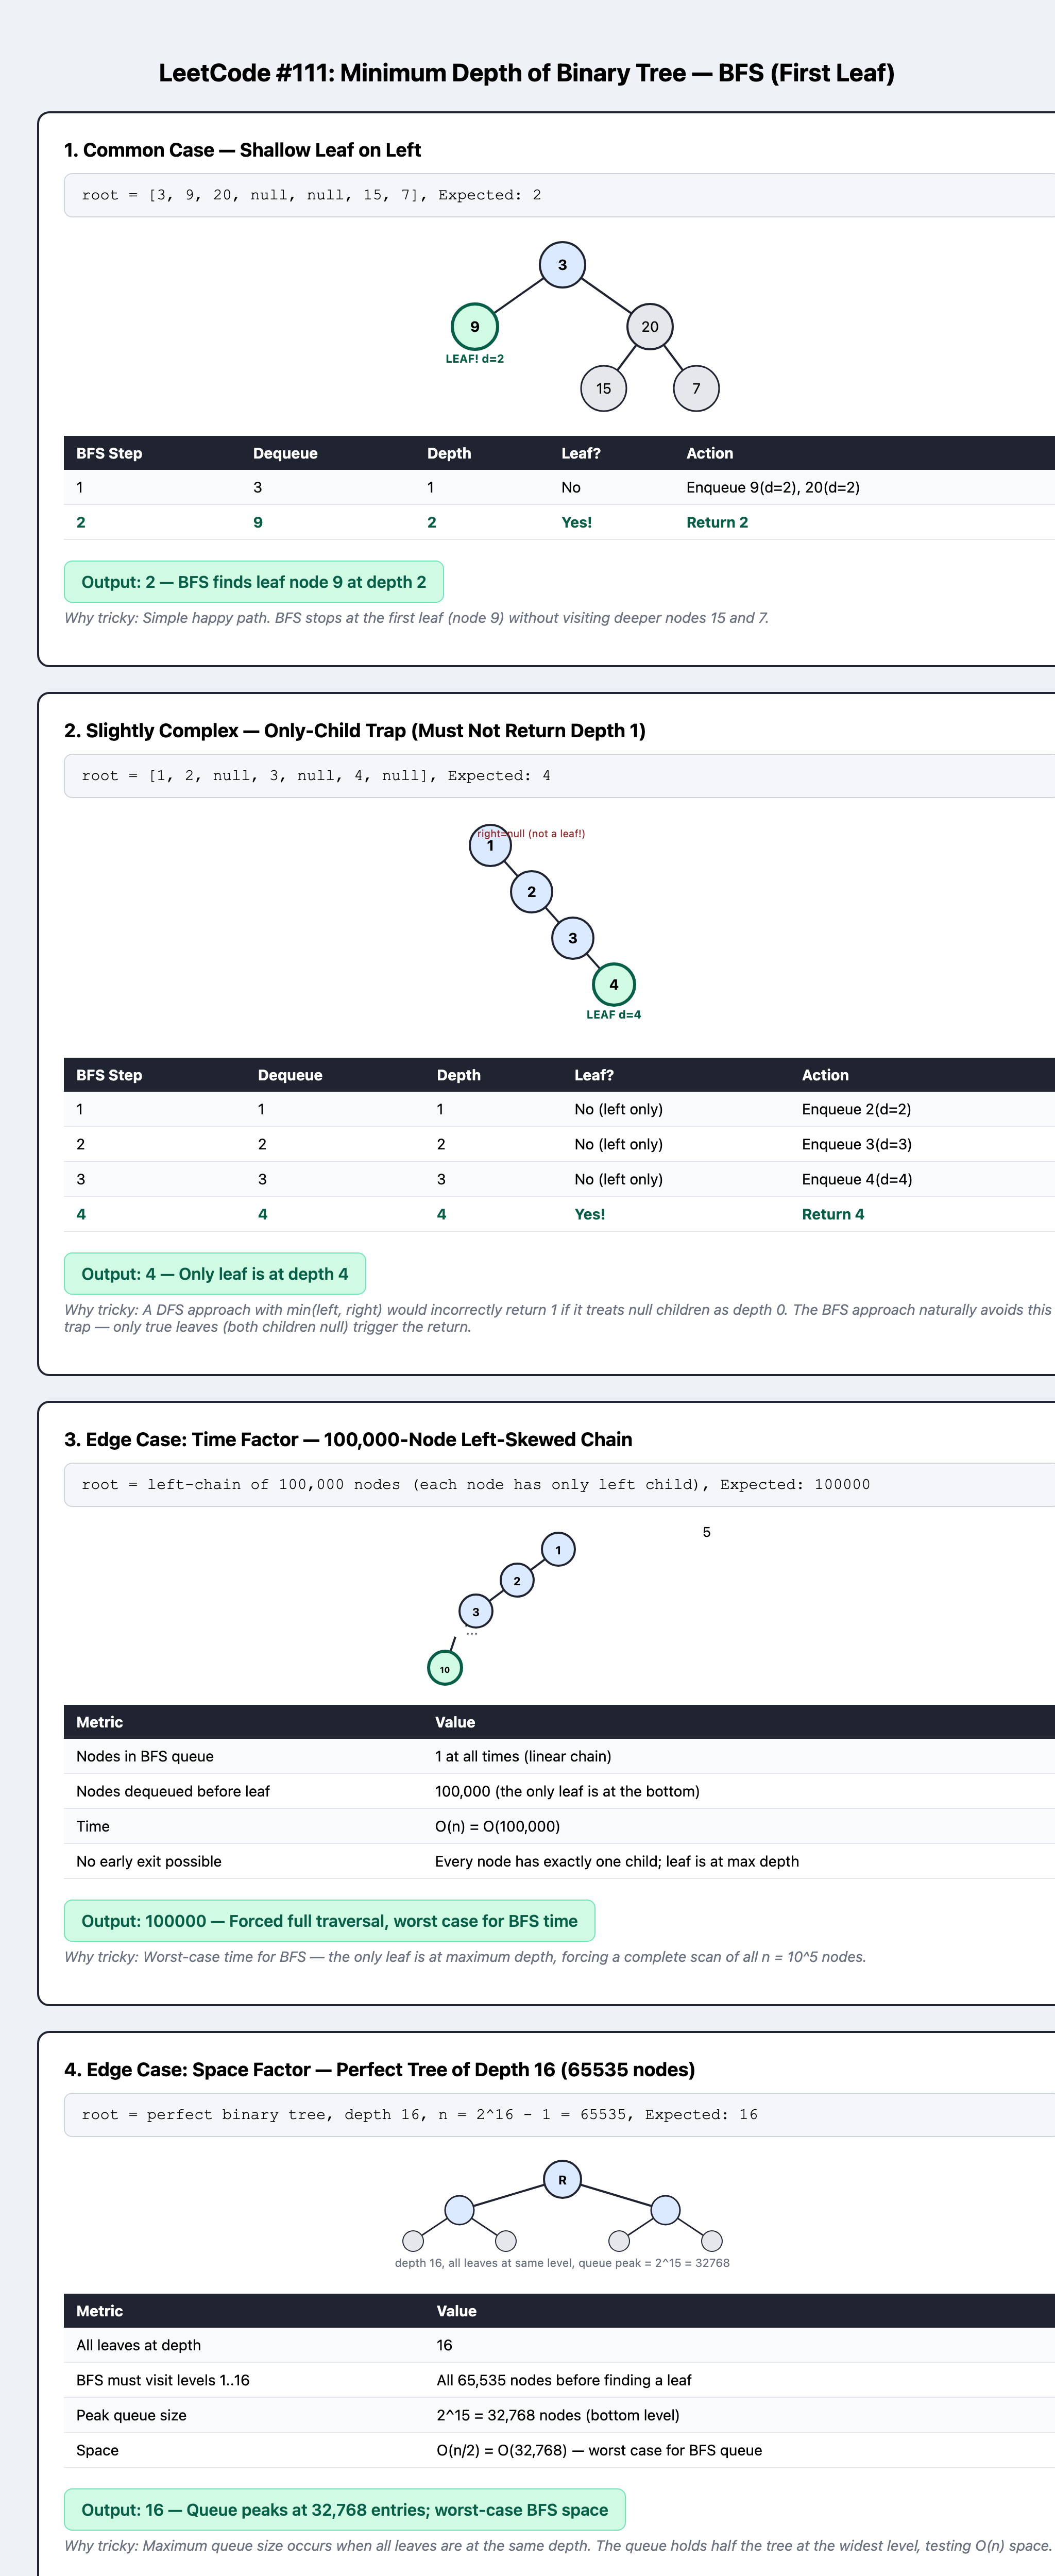